# Latent recovery for synthetic control on clinical text — results notebook

Companion to `Docs/FINAL_REPORT_latent_recovery_2026-08-11.md`. Every number below is read
from `latent/results/`; nothing is recomputed from the corpus and no note text is loaded
(PHI: aggregates and numbers only).

**Which interpreter runs this notebook:** `/data/wang/junh/envs/causal/bin/python`
(pandas 2.3.3 + matplotlib 3.10.8). That env has no `pyarrow`, so the two per-record
distributions (H2 per-target cosines, L3/L4 per-decode rows) are read from CSVs under
`latent/figures/plotdata/`, written by the same script under
`/data/wang/junh/envs/medrag/bin/python` (pandas + pyarrow, no matplotlib):

```bash
/data/wang/junh/envs/medrag/bin/python latent/scripts/make_report_figures.py prep     # parquet -> csv
/data/wang/junh/envs/causal/bin/python latent/scripts/make_report_figures.py render   # figures + tables.md
```

Everything else — the H1 grid, H2 summaries, uniqueness certificates, L3/L4 summaries —
comes straight out of the result JSONs with the stdlib `json` module.

In [1]:
import json, sys
from pathlib import Path

import pandas as pd

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 40)

LATENT = Path.cwd() if Path.cwd().name == "latent" else Path.cwd() / "latent"
sys.path.insert(0, str(LATENT / "scripts"))

import make_report_figures as M          # figure + table code, single source of truth
from make_report_figures import cell     # cell(df, arm, K, wstar, pool, sigma="sigma0")

D = M.load()                             # all JSONs, plus the plotdata CSVs if present
h1, h1c, h1o = D["h1"], D["h1_cells"], D["h1_old_cells"]
print("results dir :", M.RESULTS)
print("H1 stage    :", h1["stage"], "|", h1["generated"])
print("corpus      :", h1["n_corpus_rows"], "records,", h1["n_patients"], "patients")
print("H1 cells    :", len(h1c), "| digit-string run cells:", len(h1o))
print("plotdata    :", sorted(p.name for p in M.PLOTDATA.glob("*.csv")))

results dir : /data/wang/junh/githubs/latent-synthetic-control/preliminary/latent/results
H1 stage    : L2 (n2c2 rerun, H1 only) | 2026-08-11T17:00:17
corpus      : 1264 records, 288 patients
H1 cells    : 56 | digit-string run cells: 72
plotdata    : ['h1_grid_digitstring.csv', 'h1_grid_n2c2.csv', 'h2_per_target.csv', 'l3_copy_fraction.csv', 'l4_by_alpha.csv']


## The knobs of the H1 grid: K, wstar, m, sigma

Every H1 cell below is one setting of these knobs. In recipe terms: **K** is how many
ingredients go into the fake patient, **wstar** is the shape of the recipe, **m** is how
many jars the solver may search through, **sigma** is how smudged the recipe card is.

**K — donors blended into the fake patient.** K ∈ {2, 5, 10}. The planted target is
z = Σ wⱼ·zⱼ over K real records. More donors is harder: the blend sits in the "middle
of the crowd" and more candidates can imitate it.

**wstar — the planted weight pattern** (`wstar` column, shown as `dominant-0.9` /
`diffuse`). The two families test opposite failure modes:
- **dominant-weight** (`dominant-0.9`) — one donor gets 0.9 and the remaining 0.1 is
  spread equally (at K = 5: w* = 0.9, 0.025, 0.025, 0.025, 0.025). The advisor's "0.9"
  case: a patient who is nearly a twin of one donor. It stresses *confusion between
  near-twins* — can the solver tell the true dominant donor from its closest imitators,
  and size the 0.9 correctly? Graded by recovered w_max and top-1 donor identification.
- **diffuse** — all K weights drawn at random with no dominant donor (uniformly over
  the simplex), e.g. (0.27, 0.23, 0.32, 0.01, 0.17): a patient who is genuinely a mix
  of several donors. It stresses *faint contributions drowning* — every donor must be
  found and every middling weight sized. Graded by mean L1 over the full weight vector,
  which is why it is the harder family.

The two families came out differently, and that split is the finding: dominant-weight
met its pre-registered bars (0.884 vs 0.9, top-1 100%); diffuse missed (L1 0.452), and
the oracle/m = all controls attribute that miss entirely to retrieval — a 0.9 donor is
nearly the target itself so cosine search always surfaces it, while a 0.17 donor looks
unlike the blend and gets missed (only ~2.7 of 5 found at m = 50).

**m — candidate-pool size the solver sees** (`pool` column). Three settings, three
questions:
- `oracle` — the solver is handed exactly the K true donors, nothing else. Pure sanity
  gate; if this fails, stop everything. (It recovers to L1 ~1e-5.)
- `m50` — the realistic setting: cosine retrieval picks the 50 records most similar to
  z, and the solver sees only those. `mean_true_donors_in_pool` (~2.7 of 5) shows this
  search step is where the information is lost.
- `mall` — all 1,263 other records are candidates, so the true donors are guaranteed
  present. Separates "search failed" from "geometry failed": here recovery is exact and
  LP-certified unique (section 4).

**sigma — noise added to z before solving.** `sigma0` is a mathematically clean blend.
The nonzero setting perturbs z with Gaussian noise scaled to the residual a *real*
patient leaves when fitted with 50 donors — recovery at realistic sloppiness, i.e. the
resolution floor.

The pre-registered **decision cell** is K = 5, m = 50, sigma = 0: five donors, realistic
retrieval, clean blend, both weight families. The rest of the grid explains *why* that
cell comes out as it does — oracle and m = all isolate retrieval as the culprit;
sigma > 0 checks robustness; K = 2 / K = 10 check difficulty scaling.

## 1. H1 — the decision cell (K = 5, m = 50, sigma = 0, Qwen3-768)

The pre-registered decision cell. One weight family plants 0.9 on one donor and spreads
0.1 over the rest (**dominant-weight**); the other plants diffuse random weights
(**diffuse**).

  In H1 (where the 0.884 lives), nothing is generated in the LLM sense. The full sequence:

  1. Take 5 real patients' notes. Embed each one → 5 vectors.
  2. We compute a new vector by arithmetic: z = 0.9·(donor 1) + 0.025·(donor 2) + … This weighted average is the "fake patient." It's
  just a point in 768-d space. No LLM writes anything; there is no fake note, only a fake vector.
  3. Hide the recipe. Hand the solver z and a pool of candidates: "whose blend is this?"
  4. The solver returns weights. The 0.9 ingredient came back as 0.884.

  So 0.884 measures one thing only: if a patient truly is a 90/10 blend of others, can the machinery see that from the vectors? Yes.

In [2]:
v = h1["verdicts"]["qwen3"]
decision = pd.DataFrame([
    {"metric": "dominant 0.9: recovered w_max",
     "value": f"{v['K5_m50_sigma0_spiky_mean_w_max']:.4f}",
     "error": f"{v['K5_m50_sigma0_spiky_wmax_err']:.4f} "
              f"[{v['K5_m50_sigma0_spiky_wmax_err_ci'][0]:.4f}, {v['K5_m50_sigma0_spiky_wmax_err_ci'][1]:.4f}]",
     "pre-registered bar": "support if err <= 0.10", "meets bar": True},
    {"metric": "dominant-weight: top-1 donor found",
     "value": f"{v['K5_m50_sigma0_spiky_top1']:.1%}", "error": "",
     "pre-registered bar": "support if >= 90%", "meets bar": True},
    {"metric": "diffuse: mean L1(w_hat, w*)",
     "value": f"{v['K5_m50_sigma0_dirichlet_mean_l1']:.4f}",
     "error": f"CI [{v['K5_m50_sigma0_dirichlet_l1_ci'][0]:.4f}, {v['K5_m50_sigma0_dirichlet_l1_ci'][1]:.4f}]",
     "pre-registered bar": "support if <= 0.30, refute if > 0.25 dominant-weight err", "meets bar": False},
    {"metric": "diffuse: top-1 donor found",
     "value": f"{v['K5_m50_sigma0_dirichlet_top1']:.1%}", "error": "",
     "pre-registered bar": "refute if < 60%", "meets bar": True},
])
print("formal verdict:", v["verdict"], "| supported:", v["supported"], "| refuted:", v["refuted"])
rule = h1["verdicts"]["encoder_selection"]["rule"].replace("(Dirichlet)", "(diffuse family)")
print("encoder selection:", rule, "-> winner", h1["verdicts"]["encoder_selection"]["winner"])
decision

formal verdict: neither (between thresholds) | supported: False | refuted: False
encoder selection: arm with lower mean L1 at K=5, m=50, sigma=0 (diffuse family) -> winner qwen3


,metric,value,error,pre-registered bar,meets bar
0,dominant 0.9: recovered w_max,0.8840,"0.0160 [0.0155, 0.0166]",support if err <= 0.10,True
1,dominant-weight: top-1 donor found,100.0%,,support if >= 90%,True
2,"diffuse: mean L1(w_hat, w*)",0.4520,"CI [0.4281, 0.4755]","support if <= 0.30, refute if > 0.25 dominant-...",False
3,diffuse: top-1 donor found,95.6%,,refute if < 60%,True


## 2. H1 — the full m = 50 grid, plus the oracle / m=all controls

`mean_true_donors_in_pool` is the retrieval diagnostic: how many of the K planted donors the
cosine retriever actually put in the candidate pool.

In [3]:
WNAME = {"spiky": "dominant-0.9", "dirichlet": "diffuse"}   # result-file keys -> plain names
COLS = ["arm", "K", "wstar", "pool", "N", "mean_l1", "l1_ci_lo", "l1_ci_hi", "top1_recovery",
        "mean_w_max", "mean_true_donors_in_pool", "frac_all_true_donors_in_pool"]
grid50 = (h1c[(h1c.pool == "m50") & (h1c.sigma_name == "sigma0")][COLS]
          .sort_values(["arm", "K", "wstar"]).reset_index(drop=True)
          .assign(wstar=lambda d: d.wstar.map(WNAME)))
grid50

,arm,K,wstar,pool,N,mean_l1,l1_ci_lo,l1_ci_hi,top1_recovery,mean_w_max,mean_true_donors_in_pool,frac_all_true_donors_in_pool
0,biolord,2,diffuse,m50,500,0.189545,0.165738,0.214627,1.000,0.723431,1.518,0.518
1,biolord,2,dominant-0.9,m50,500,0.231125,0.224086,0.237795,1.000,0.874447,1.100,0.100
2,biolord,5,diffuse,m50,500,0.732381,0.699361,0.764572,0.914,0.413987,2.104,0.002
3,biolord,5,dominant-0.9,m50,500,0.230822,0.228402,0.233259,1.000,0.880919,1.184,0.000
4,biolord,10,diffuse,m50,500,1.258295,1.226319,1.288348,0.728,0.268413,2.174,0.000
5,biolord,10,dominant-0.9,m50,500,0.230253,0.228436,0.232045,1.000,0.881744,1.394,0.000
6,qwen3,2,diffuse,m50,500,0.108254,0.091616,0.124405,1.000,0.736176,1.616,0.616
7,qwen3,2,dominant-0.9,m50,500,0.205328,0.197733,0.213057,1.000,0.882150,1.152,0.152
8,qwen3,5,diffuse,m50,500,0.451965,0.428085,0.475506,0.956,0.429322,2.658,0.010
9,qwen3,5,dominant-0.9,m50,500,0.221893,0.219352,0.224332,1.000,0.883990,1.220,0.000


In [4]:
controls = (h1c[(h1c.pool != "m50") & (h1c.sigma_name == "sigma0")][COLS]
            .sort_values(["arm", "K", "wstar", "pool"]).reset_index(drop=True)
            .assign(wstar=lambda d: d.wstar.map(WNAME)))
gate = h1["verdicts"]["oracle_gate"]
print("oracle gate (max mean L1 over oracle sigma=0 cells, threshold "
      f"{gate['qwen3']['threshold']}):")
for arm in ("qwen3", "biolord"):
    print(f"   {arm:8s} {gate[arm]['max_mean_l1_over_oracle_sigma0_cells']:.3e}  "
          f"passed={gate[arm]['passed']}")
controls

oracle gate (max mean L1 over oracle sigma=0 cells, threshold 0.01):
   qwen3    1.462e-05  passed=True
   biolord  1.680e-05  passed=True


,arm,K,wstar,pool,N,mean_l1,l1_ci_lo,l1_ci_hi,top1_recovery,mean_w_max,mean_true_donors_in_pool,frac_all_true_donors_in_pool
0,biolord,2,diffuse,oracle,500,1.071834e-15,9.901621e-16,1.162402e-15,1.0,0.746371,2.0,1.0
1,biolord,2,dominant-0.9,oracle,500,1.420503e-15,1.328851e-15,1.516678e-15,1.0,0.900000,2.0,1.0
2,biolord,5,diffuse,mall,50,3.309125e-05,2.996807e-05,3.630093e-05,1.0,0.464628,5.0,1.0
3,biolord,5,diffuse,oracle,500,6.111239e-06,5.601144e-06,6.637582e-06,1.0,0.453101,5.0,1.0
4,biolord,5,dominant-0.9,mall,50,3.252868e-05,2.944979e-05,3.597312e-05,1.0,0.899997,5.0,1.0
5,biolord,5,dominant-0.9,oracle,500,4.827287e-06,4.334237e-06,5.328444e-06,1.0,0.900000,5.0,1.0
6,biolord,10,diffuse,oracle,500,1.680462e-05,1.596000e-05,1.773281e-05,1.0,0.295133,10.0,1.0
7,biolord,10,dominant-0.9,oracle,500,1.519162e-05,1.432798e-05,1.604166e-05,1.0,0.900000,10.0,1.0
8,qwen3,2,diffuse,oracle,500,1.079548e-15,1.008566e-15,1.154973e-15,1.0,0.746371,2.0,1.0
9,qwen3,2,dominant-0.9,oracle,500,1.417616e-15,1.336542e-15,1.498868e-15,1.0,0.900000,2.0,1.0


In [5]:
# where the diffuse error lives: same solver, same targets, only the pool changes
# ("dirichlet" is the diffuse family's key inside the result files)
loc = pd.DataFrame([
    {"pool": lab,
     "mean_L1": cell(h1c, "qwen3", 5, "dirichlet", p).mean_l1,
     "true_donors_in_pool": cell(h1c, "qwen3", 5, "dirichlet", p).mean_true_donors_in_pool,
     "all_5_in_pool": cell(h1c, "qwen3", 5, "dirichlet", p).frac_all_true_donors_in_pool,
     "top1": cell(h1c, "qwen3", 5, "dirichlet", p).top1_recovery}
    for p, lab in (("oracle", "oracle (true donors handed over)"),
                   ("mall", "m = all (1,263 candidates)"),
                   ("m50", "m = 50 (cosine retrieval)"))
])
loc

,pool,mean_L1,true_donors_in_pool,all_5_in_pool,top1
0,oracle (true donors handed over),0.000006,5.000,1.00,1.000
1,"m = all (1,263 candidates)",0.000026,5.000,1.00,1.000
2,m = 50 (cosine retrieval),0.451965,2.658,0.01,0.956


## 3. H2 — cross-representation consistency, v1 and v2

Weights fitted twice on the same 50 donors for each of 287 real patients: once in
UMLS-concept-bag space, once in text-latent space. v2 repeats it after the NegEx negation
filter.

In [6]:
h2 = pd.DataFrame([
    {"version": ver, "arm": arm,
     "mean weight cosine": s["mean_weight_cosine"],
     "CI lo": s["weight_cosine_ci"][0], "CI hi": s["weight_cosine_ci"][1],
     "null mean": s["null_mean_cosine"],
     "null IQR lo": s["null_cosine_iqr"][0], "null IQR hi": s["null_cosine_iqr"][1],
     "null p95": s["null_cosine_p95"],
     "top-1 agreement": s["top1_agreement"], "top-1 vs null": s["top1_ratio_vs_null"],
     "verdict": s["verdict"]}
    for ver, key in (("v1", "h2v1"), ("v2", "h2v2"))
    for arm, s in D[key]["arms"].items()])
print("negation handling v2:", D["h2v2"]["negation_handling"][:160])
h2

negation handling v2: negspacy 1.0.4 NegEx, en_clinical termset (bags v2)


,version,arm,mean weight cosine,CI lo,CI hi,null mean,null IQR lo,null IQR hi,null p95,top-1 agreement,top-1 vs null,verdict
0,v1,qwen3,0.425067,0.410719,0.440393,0.371334,0.280461,0.465666,0.593731,0.080139,1.533333,refuted (within null IQR)
1,v1,biolord,0.389995,0.376265,0.404466,0.343667,0.256831,0.434128,0.541448,0.062718,1.058824,refuted (within null IQR)
2,v2,qwen3,0.421523,0.407242,0.435741,0.378801,0.292243,0.460239,0.548626,0.083624,1.333333,refuted (within null IQR)
3,v2,biolord,0.377803,0.363613,0.392382,0.348021,0.251585,0.445276,0.561627,0.059233,0.944444,refuted (within null IQR)


In [7]:
# per-target distributions behind the summary (from plotdata/h2_per_target.csv)
pt = D["h2_pt"]
pt[pt.arm == "qwen3"].groupby("version")[["cos", "null_cos"]].describe().T

version                 v1          v2
cos      count  287.000000  287.000000
         mean     0.425067    0.421523
         std      0.126949    0.122869
         min      0.132419    0.114906
         25%      0.334333    0.337535
         50%      0.425012    0.414481
         75%      0.496426    0.501862
         max      0.917302    0.741227
null_cos count  287.000000  287.000000
         mean     0.371334    0.378801
         std      0.131937    0.114803
         min      0.033732    0.117745
         25%      0.280461    0.292243
         50%      0.353946    0.383140
         75%      0.465666    0.460239
         max      0.754074    0.687743

## 4. Uniqueness certificates

Does the m = all exact recovery reflect a unique optimum, or a lucky pick from an exact-fit
polytope? Per-coordinate LP ranges plus random warm restarts, 20 pseudo-targets.

In [8]:
u = D["uniq"]
a, lp = u["aggregate"]["mall"], u["aggregate"]["mall"]["lp_ranges"]
m50u = u["aggregate"]["m50"]
uniq = pd.DataFrame([
    ["exact fit feasible (m = all)", f"{a['n_exact_fit_feasible']} / {a['n_targets']}"],
    ["unconstrained affine solution dim", a["affine_solution_dim"][0]],
    ["QP strictly convex (m = all)", f"{a['n_qp_strictly_convex']} / {a['n_targets']}"],
    ["LP coords probed", lp["total_coords_probed"]],
    ["LP coords with nonzero range", lp["n_coords_with_nonzero_range"]],
    ["max LP range over everything", f"{lp['max_range_over_everything']:.3e}"],
    ["donors that can carry weight", lp["n_donors_that_can_carry_weight"][0]],
    ["max off-support mass", f"{a['max_offsupport_mass']:.3e}"],
    ["warm restarts per target", f"{u['n_restarts_per_target']} + 1 primary = 11"],
    ["max pairwise L1 across restarts", f"{a['restarts']['max_pairwise_l1_over_targets']:.3e}"],
    ["max L1 to w* across restarts", f"{a['restarts']['max_l1_to_wstar_over_targets']:.3e}"],
    ["m = 50: exact fit feasible", f"{m50u['n_exact_fit_feasible']} / {m50u['n_targets']}"],
    ["m = 50: QP strictly convex", f"{m50u['n_qp_strictly_convex']} / {m50u['n_targets']}"],
    ["m = 50: mean L1 to w*", f"{m50u['restarts']['mean_l1_to_wstar_over_targets']:.4f}"],
], columns=["certificate", "value"])
print(u["question"][:200])
uniq

does the m=all exact weight recovery reflect a UNIQUE optimum, or a lucky pick from an exact-fit polytope (Abadie & L'Hour JASA 2021; Eslami arXiv 2607.25074)?


,certificate,value
0,exact fit feasible (m = all),20 / 20
1,unconstrained affine solution dim,494
2,QP strictly convex (m = all),0 / 20
3,LP coords probed,25260
4,LP coords with nonzero range,0
5,max LP range over everything,6.204e-11
6,donors that can carry weight,5
7,max off-support mass,1.685e-12
8,warm restarts per target,10 + 1 primary = 11
9,max pairwise L1 across restarts,5.883e-05


## 5. H3 / H4 — the decoder stages and the copy diagnostic

In [9]:
l3, l4, cp = D["l3"], D["l4"], D["copy"]
dec = pd.DataFrame([
    ["H3 median perplexity, generated", f"{l3['a_perplexity']['generated']['median']:.3f}"],
    ["H3 median perplexity, real records", f"{l3['a_perplexity']['real_records_full']['median']:.3f}"],
    ["H3 ratio of medians", f"{l3['a_perplexity']['ratio_of_medians_generated_over_real']:.3f}"],
    ["H3 median cycle rank of z* (of 1,265)", f"{l3['b_cycle_consistency']['median_rank']:.0f}"],
    ["H3 cycle top-5% rate", f"{l3['b_cycle_consistency']['top_5pct_rate']:.1%}"],
    ["H3 similar-mixtures Spearman", f"{l3['c_similar_mixtures_similar_notes']['sampled_pairs']['spearman_rho']:.3f}"],
    ["H3 verdict", l3["verdict"]["verdict"]],
    ["copy fraction (pooled) median", f"{cp['l3']['pooled_over_donors']['median']:.3f}"],
    ["copy fraction >= 80%", f"{cp['l3']['share_pooled_copy_over_80pct']:.1%}"],
    ["copy fraction >= 50%", f"{cp['l3']['share_pooled_copy_over_50pct']:.1%}"],
    ["H4 mean Spearman, logistic scorer", f"{l4['verdict']['mean_spearman']['lr_generated']:.3f}"],
    ["H4 mean Spearman, LLM judge", f"{l4['verdict']['mean_spearman']['llm_judge']:.3f}"],
    ["H4 verdict", l4["verdict"]["verdict"]],
], columns=["metric", "value"])
dec

,metric,value
0,"H3 median perplexity, generated",8.962
1,"H3 median perplexity, real records",9.119
2,H3 ratio of medians,0.983
3,"H3 median cycle rank of z* (of 1,265)",2
4,H3 cycle top-5% rate,88.8%
5,H3 similar-mixtures Spearman,0.280
6,H3 verdict,supported
7,copy fraction (pooled) median,0.835
8,copy fraction >= 80%,54.2%
9,copy fraction >= 50%,75.6%


In [10]:
by_alpha = pd.DataFrame([
    {"alpha": float(k),
     "mean P(ADVANCED-CAD)": v["mean_severity_lr_generated"],
     "mean LLM judge (1-10)": v["mean_judge"],
     "median perplexity": v["median_ppl"],
     "copy from severe record": cp["l4"]["by_alpha"][k]["met_median"],
     "copy from non-severe record": cp["l4"]["by_alpha"][k]["notmet_median"]}
    for k, v in sorted(l4["by_alpha"].items(), key=lambda kv: float(kv[0]))])
by_alpha

,alpha,mean P(ADVANCED-CAD),mean LLM judge (1-10),median perplexity,copy from severe record,copy from non-severe record
0,0.00,0.174820,3.60,8.562317,0.000000,0.949620
1,0.25,0.181727,4.18,8.596113,0.076702,0.468320
2,0.50,0.187857,4.00,8.656465,0.016829,0.553535
3,0.75,0.253247,4.60,8.303065,0.637543,0.004540
4,1.00,0.268245,4.70,8.497561,0.749039,0.000000


So the decoder does roughly follow the majority — but as a hard switch, not a dial. The damning row is α = 0.5: a faithful decoder
  should produce a half-and-half note, but it just serves the non-severe donor's note. The "switch at 0.75" means the copied identity
  flips somewhere between 0.5 and 0.75. That step function instead of a smooth slide is exactly why H4 was refuted.

### Reconciling the H3 copy statistics with the H4 switch — not a contradiction

At first glance these clash: H3 says the donor being copied is the top-weight donor only
56% of the time (and in the diffuse family, median overlap with the top-weight donor is
0.00), while H4 shows the copying following the majority side of α. The key variable is
**whether a clearly dominant donor exists**.

First, what the copy number means: the diagnostic is the share of the generated note's
**word 8-grams** that occur verbatim in a given source note. Two notes with no lifting
share essentially no 8-grams — the internal calibration is the diffuse family itself,
where median overlap with the top-weight donor is 0.00 even though that donor
contributed ~0.3 of the blend. Against that zero baseline, 0.65 overlap means most of
the text was lifted verbatim from that one donor. The gap to 1.0 is largely mechanical,
not evidence of blending: generation capped at 800 tokens (median real record ~1,022),
donor notes truncated in the prompt, light paraphrase — even at α = 1.0, where the task
is to render *one* patient with no mixing, overlap reaches only 0.75 (0.95 at the other
endpoint, α = 0).

- **Dominant donor present** (dominant-weight 0.9 in H3; α = 0.75 or 1.0 in H4): *which*
  donor gets lifted from follows the weight — 0.65 median overlap with the 0.9 donor in
  H3, 0.75 with the severe donor at α = 1.0, against the 0.00 no-lifting baseline.
- **Weights close** (diffuse in H3, e.g. 0.32 vs 0.27; α = 0.25–0.5 in H4): the LLM
  still lifts most of its text from *some single* donor (pooled median 0.84) but which
  one is no longer guided by the weights — hence 0.00 median overlap with the
  top-weight donor. The 56% pooled figure mixes the two families: dominant-weight pulls
  it up, diffuse drags it toward chance.

H4 shows the same weight-blindness in 2-donor form: at α = 0.5 a faithful decoder should
blend (or at least be at 50/50 confusion), yet the output is 55% lifted from the
non-severe donor and 2% from the severe one. The design detail that likely explains
*which* donor wins the ambiguous cases: the two donor notes were always given to the LLM
in a fixed order, **non-severe first**, and at every ambiguous α (0.25, 0.5) it copies
the first-listed donor. The switch landing at α ≈ 0.75 rather than 0.5 is what a
position bias toward the first donor would produce — the weight only wins once it is
overwhelming. (This position-bias reading is an inference from the fixed order plus the
α = 0.25/0.5 rows; the order-swapped control that would prove it was not run.)

**One story covering both experiments:** the LLM decoder is a single-donor copier; the
planted weight controls *which* donor gets copied only when that weight is near 1, and
below that the choice falls to weight-irrelevant factors such as prompt position. This
is stronger than either experiment alone — it rules out the charitable reading "at least
it respects the majority."

## 6. Figures

The same functions the script calls, rendered inline.

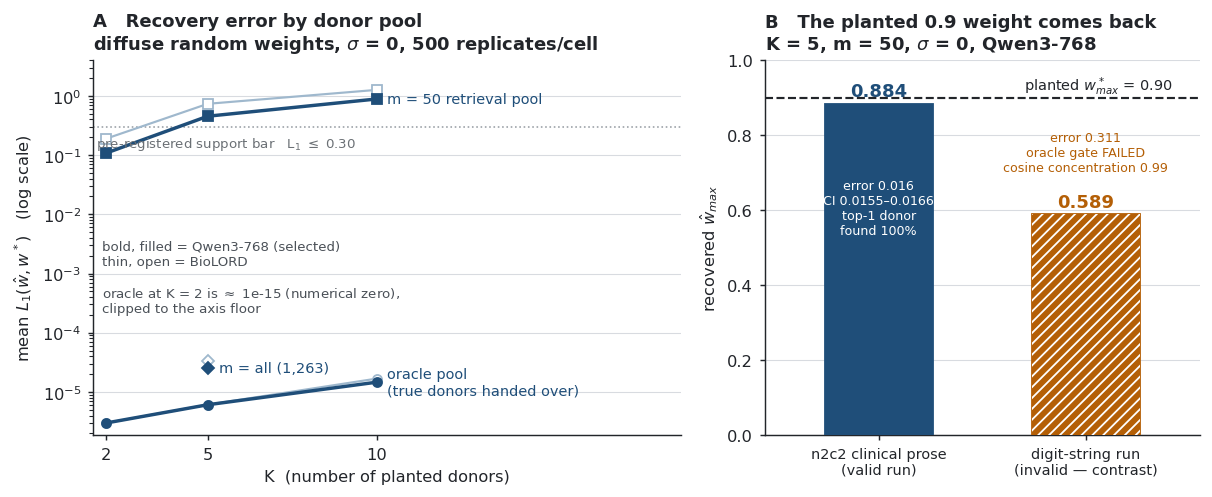

In [11]:
%matplotlib inline
import matplotlib.pyplot as plt

fig = M.fig1(D); plt.show()

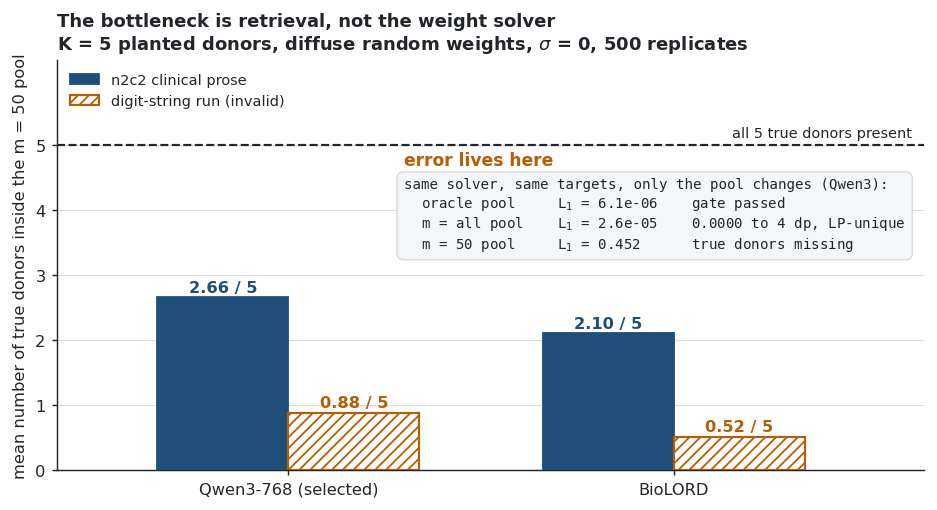

In [12]:
fig = M.fig2(D); plt.show()

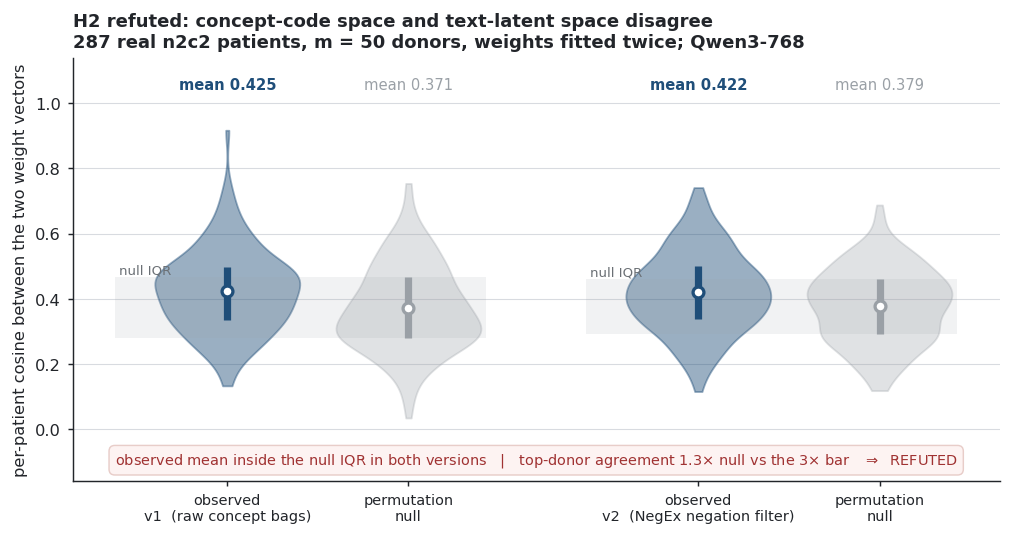

In [13]:
fig = M.fig3(D); plt.show()

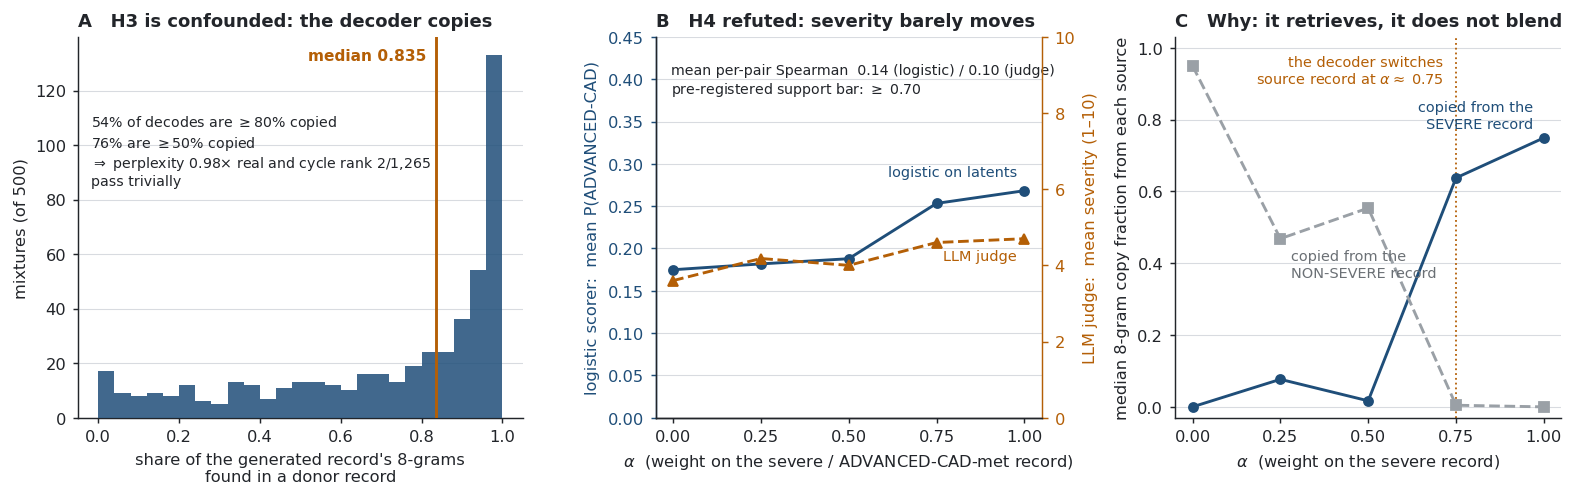

In [14]:
fig = M.fig4(D); plt.show()

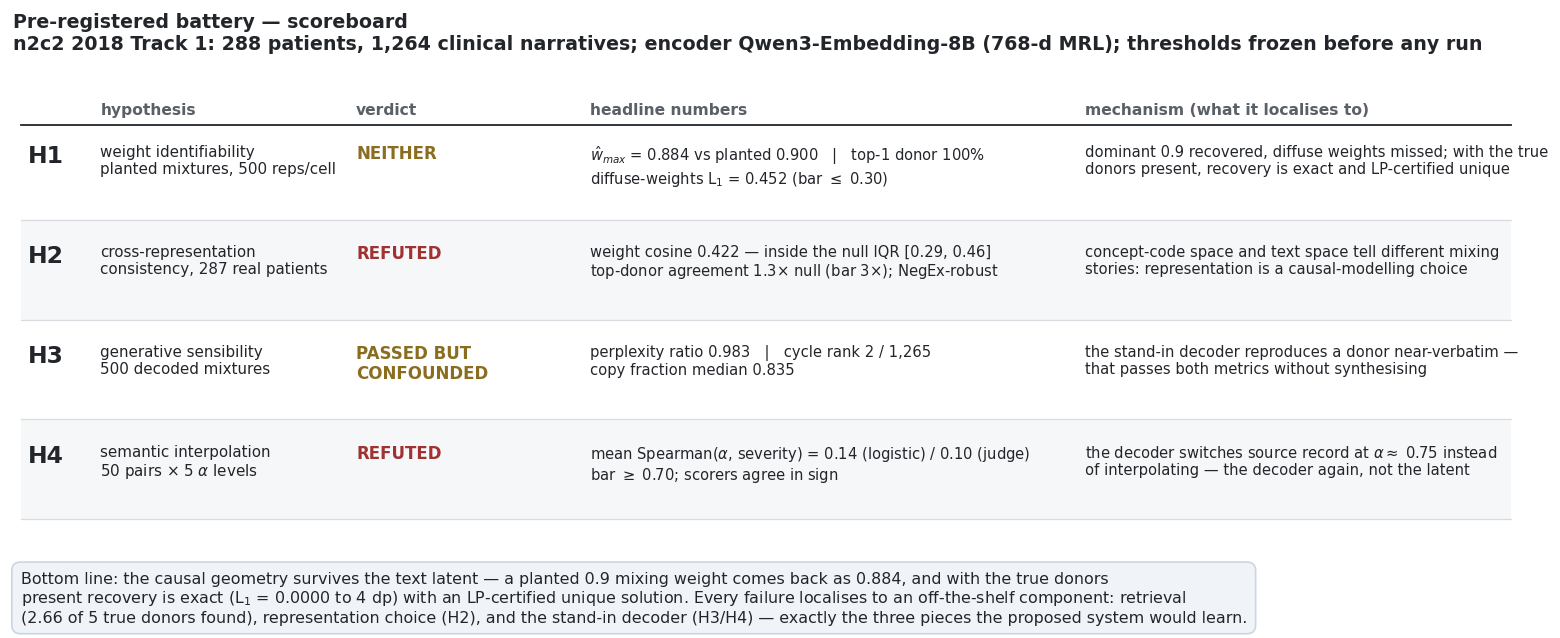

In [15]:
fig = M.fig5(D); plt.show()

## 7. Verification against the FINAL_REPORT

Each quoted number in `Docs/FINAL_REPORT_latent_recovery_2026-08-11.md` re-checked against
the artifact it came from.

In [16]:
checks = M.verify(D)

[ok ] H1 dominant-weight w_max = 0.884              report=0.884        artifact=0.884
[ok ] H1 dominant-weight w_max err = 0.016          report=0.016        artifact=0.01603
[ok ] H1 err CI lo = .0155                          report=0.0155       artifact=0.01549
[ok ] H1 err CI hi = .0166                          report=0.0166       artifact=0.01659
[ok ] H1 dominant-weight top-1 = 100%               report=1            artifact=1
[ok ] H1 diffuse L1 = 0.452                         report=0.452        artifact=0.452
[ok ] H1 verdict = 'neither'                        report=neither      artifact=neither (between thresholds)
[ok ] oracle gate L1 ~ 1.5e-05                      report=1.5e-05      artifact=1.462e-05
[ok ] m=all L1 = 0.0000 (4 dp)                      report=0.0000       artifact=2.578e-05
[ok ] m=50 true donors = 2.66/5                     report=2.66         artifact=2.658
[ok ] m=50 '1.0% of replicates have all 5' (diffuse) report=1.0%         artifact=1.0%
[ok ] m=50